# ATHENA CAMM Hackathon 01
## Boundary Detection + Atom Finding

**September 2026**

A scientific algorithm should not only work once. It should be **explainable, testable, fast, consistent, and robust**.

### Challenge 1 — Boundary Detection
- Dataset: **SiSb**
- Input: **12 HAADF-STEM images**
- Goal: detect the crystalline–amorphous boundary

### Challenge 2 — Atom Finding
- Dataset: **YBCO**
- Input: atomic-resolution STEM images
- Goal: return atomic-column coordinates

All helper functions are kept in:

```text
utils.py
```

The notebook stays focused on the two functions you are asked to improve.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_16_11092026/boundary_detection.ipynb)

## 1. Setup

In [1]:
# %pip install -q pyTEMlib ipympl

In [2]:
# # Download only the files needed for this challenge
# !git clone -q --filter=blob:none --no-checkout -b k4my4r \
#     https://github.com/kbarakati/athena_camm_hackathon.git athena

# %cd athena
# !git sparse-checkout init --cone
# !git sparse-checkout set docs/day_16_11092026
# !git checkout -q

# %cd docs/day_16_11092026


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

from utils import (
    resolve_data_dir,
    list_emd_files,
    robust_normalize,
    load_haadf,
    show_image_grid,
    plot_ground_truth_grid,
    plot_boundary_result,
    evaluate_against_ground_truth,
    summarize_accuracy,
    evaluate_robustness,
    summarize_robustness,
    evaluate_speed,
    summarize_speed,
    plot_atom_result,
    validate_atom_output,
    atom_repeatability,
    atom_noise_robustness,
    atom_photometric_robustness,
)

You don't have gwyfile installed.     If you wish to open .gwy files, you will need to      install it (pip install gwyfile) before attempting.
Symmetry functions of spglib enabled


In [4]:
DATA_DIR = resolve_data_dir()

SISB_DIR = DATA_DIR / "SiSb"
YBCO_DIR = DATA_DIR / "YBCO"
GT_DIR = DATA_DIR / "SiSb_ground_truth"

print("DATA_DIR:", DATA_DIR)
print("SiSb:", SISB_DIR.exists())
print("YBCO:", YBCO_DIR.exists())
print("SiSb ground truth:", GT_DIR.exists())

DATA_DIR: /Users/kbarakat/Library/CloudStorage/OneDrive-UniversityofTennessee 2/vs_code/2026/athena_camm_hackathon/docs/day_16_11092026/data
SiSb: True
YBCO: True
SiSb ground truth: True


# Challenge 1 — Boundary Detection

## Goal

Write:

```python
boundary = detect_boundary(image)
```

The function must return a **2D boolean array with the same shape as the input image**.

`True` means that pixel belongs to the predicted crystalline–amorphous boundary.

## 2. Load the SiSb challenge images

In [5]:
all_sisb_files = list_emd_files(SISB_DIR)

N_SISB = 12
sisb_files = all_sisb_files[:N_SISB]

sisb_images = [
    load_haadf(file)
    for file in sisb_files
]

sisb_titles = [
    file.stem.split("-")[0].strip()
    for file in sisb_files
]

print(f"Using {len(sisb_files)} SiSb images")

Using 12 SiSb images


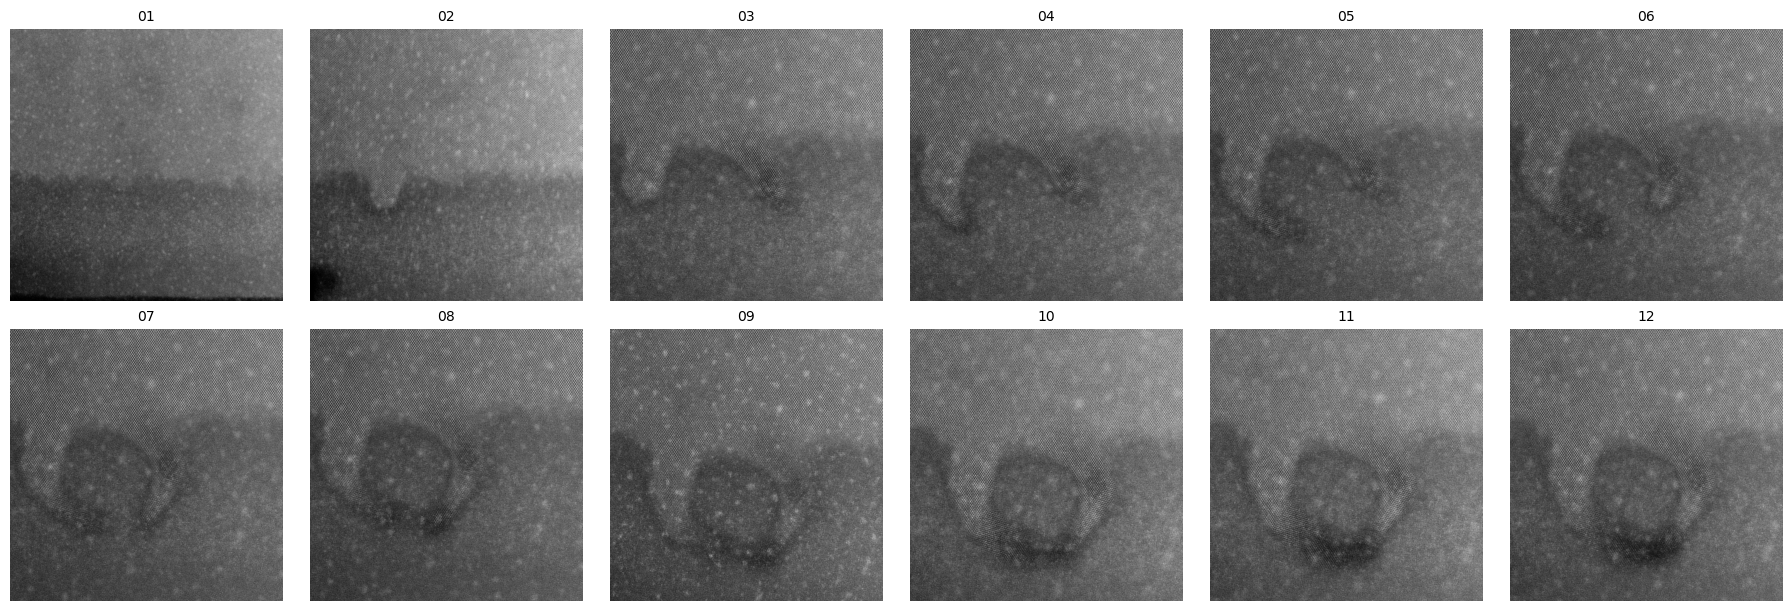

In [6]:
show_image_grid(
    sisb_images,
    titles=sisb_titles,
    rows=2,
)

### Human ground truth

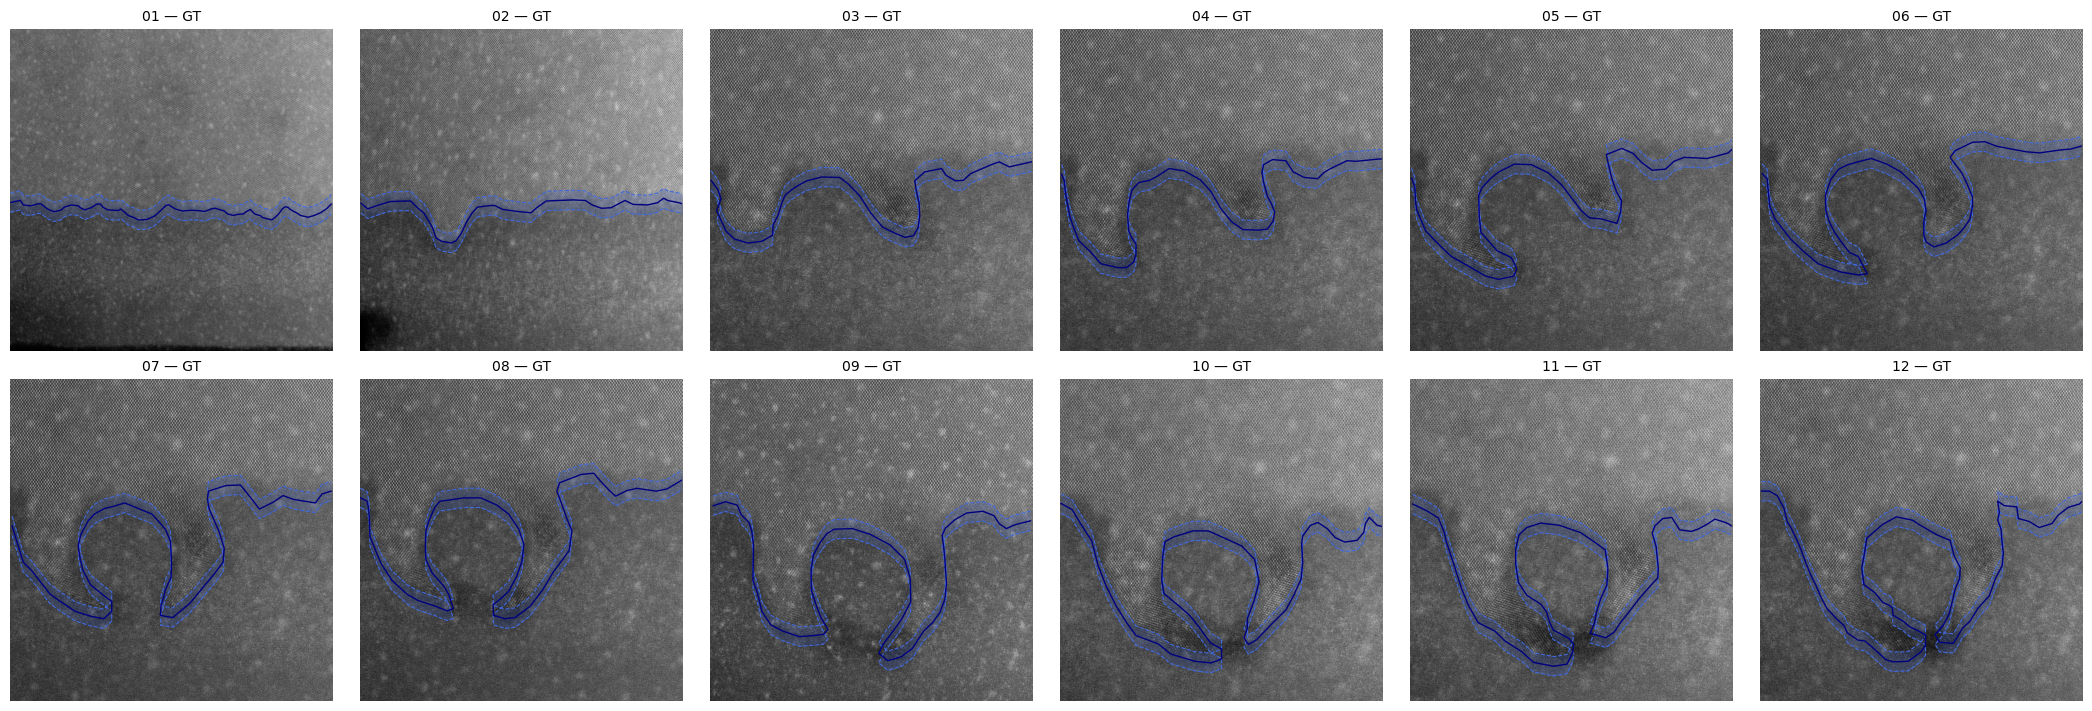

In [7]:
plot_ground_truth_grid(
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    rows=2,
)

## 3. Build your boundary detector

A simple texture-based baseline is provided.

You may completely replace the code between the two markers.  
Do **not** change the function name, input, or required output format.

In [71]:
# import numpy as np
from scipy.ndimage import gaussian_filter

def difference_of_gaussians(image, sigma_small=1.0, sigma_large=20.0):

    image = np.asarray(image, dtype=float)

    blur_small = gaussian_filter(image, sigma=sigma_small)
    blur_large = gaussian_filter(image, sigma=sigma_large)

    dog = blur_small - blur_large

    return dog

In [119]:
img = sisb_images[10].astype(float).copy()
img.shape

(2048, 2048)

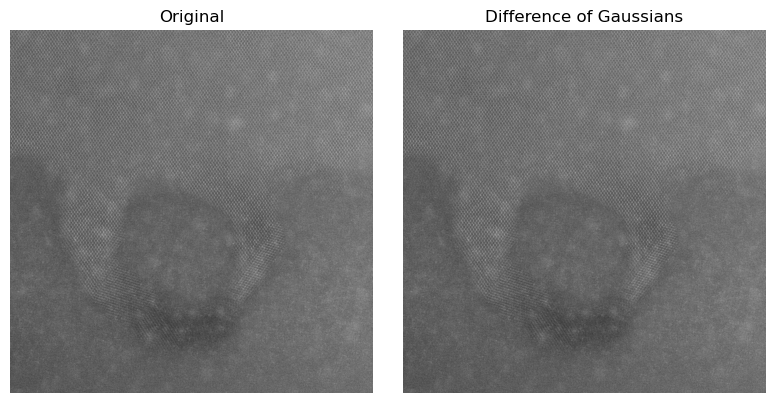

In [75]:
img = sisb_images[10].astype(float).copy()

dog = sisb_images[10].astype(float).copy()

dog -= dog.min()
dog /= dog.max()

fig, axes = plt.subplots(1, 2, figsize =(8, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(dog, cmap="gray")
axes[1].set_title("Difference of Gaussians")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [189]:
# def detect_boundary(image):

#     # ============================================================
#     # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
#     # ============================================================

#     # 1. Normalize
#     x = robust_normalize(image)

#     # 2. Estimate local texture using local variance
#     sigma_texture = 10

#     local_mean = ndimage.gaussian_filter(
#         x,
#         sigma=sigma_texture
#     )

#     local_mean_squared = ndimage.gaussian_filter(
#         x**2,
#         sigma=sigma_texture
#     )

#     local_variance = np.maximum(
#         local_mean_squared - local_mean**2,
#         0
#     )

#     # 3. Smooth the texture map
#     texture = ndimage.gaussian_filter(
#         local_variance,
#         sigma=40
#     )

#     # 4. Separate the two texture regimes
#     threshold = np.median(texture)
#     phase_mask = texture > threshold

#     # 5. Clean the phase segmentation
#     phase_mask = ndimage.binary_opening(
#         phase_mask,
#         iterations=6
#     )

#     phase_mask = ndimage.binary_closing(
#         phase_mask,
#         iterations=1
#     )

#     # 6. Extract the interface
#     dilated = ndimage.binary_dilation(
#         phase_mask,
#         iterations=1
#     )

#     eroded = ndimage.binary_erosion(
#         phase_mask,
#         iterations=6
#     )

#     boundary = dilated ^ eroded

#     # 7. Ignore 10-pixel image border
#     border = 10

#     boundary[:border, :] = False
#     boundary[-border:, :] = False
#     boundary[:, :border] = False
#     boundary[:, -border:] = False

#     # ============================================================
#     # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
#     # ============================================================

#     return boundary.astype(bool)

In [ ]:
import numpy as np
from scipy import ndimage, fft


def _spacing(x):
    n = min(512, x.shape[1], max(32, x.shape[0] // 4))
    crop = x[:n, (x.shape[1]-n)//2:(x.shape[1]+n)//2]
    crop = crop - ndimage.gaussian_filter(crop, 4)
    p = np.abs(fft.fft2(crop * np.outer(np.hanning(n), np.hanning(n)) ))**2
    fy, fx = np.meshgrid(fft.fftfreq(n), fft.fftfreq(n), indexing='ij')
    r = np.hypot(fy, fx)
    # Favor narrow spectral peaks over broad low-frequency contrast.
    p = p / (ndimage.gaussian_filter(p, 3, mode='wrap') + 1e-12)
    p[(r < 1/24) | (r > 1/3)] = 0
    return float(1 / r[np.unravel_index(np.argmax(p), p.shape)])


def _path(cost, penalty, max_step=3):
    h, w = cost.shape
    back = np.zeros((h, w), np.int16)
    previous = cost[:, 0].copy()
    rows = np.arange(h)
    shifts = np.arange(-max_step, max_step+1)
    for col in range(1, w):
        candidates = np.full((len(shifts), h), np.inf)
        for k, shift in enumerate(shifts):
            src = rows + shift
            ok = (src >= 0) & (src < h)
            candidates[k, ok] = previous[src[ok]] + penalty * shift**2
        best = candidates.argmin(axis=0)
        back[:, col] = shifts[best]
        previous = cost[:, col] + candidates[best, rows]
    path = np.empty(w, int)
    path[-1] = previous.argmin()
    for col in range(w-1, 0, -1):
        path[col-1] = path[col] + back[path[col], col]
    return path


def detect_boundary(image, *, lattice_spacing=None, crystal_side='top',
                    window_periods=5, smoothness=0.15, return_debug=False):
    """Return an original-size bool mask; optionally return diagnostic maps.

    The feature is power near lattice peaks relative to all band power.
    A regularized path separates the top and bottom reference distributions.
    Missing patches have zero evidence; the path interpolates through them.
    Returned mask excludes missing pixels but not the entire affected window.
    """
    x = np.asarray(image, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError('Expected a 2D grayscale image.')
    if crystal_side not in ('top', 'bottom'):
        raise ValueError("crystal_side must be 'top' or 'bottom'")
    if window_periods <= 0 or smoothness < 0:
        raise ValueError('window_periods must be positive; smoothness nonnegative.')
    if lattice_spacing is not None and (not np.isfinite(lattice_spacing) or lattice_spacing < 2):
        raise ValueError('lattice_spacing must be finite and at least 2 pixels.')
    valid = np.isfinite(x)
    empty = np.zeros(x.shape, bool)
    if min(x.shape) < 32 or not valid.any():
        return (empty, {'status': 'insufficient_data'}) if return_debug else empty
    lo, hi = np.percentile(x[valid], [1, 99])
    if hi <= lo:
        return (empty, {'status': 'constant_image'}) if return_debug else empty
    x = np.clip((np.where(valid, x, lo)-lo)/(hi-lo), 0, 1)
    if crystal_side == 'bottom':
        x, valid = x[::-1], valid[::-1]
    if not valid.all():
        indices = ndimage.distance_transform_edt(~valid, return_distances=False, return_indices=True)
        x = x[tuple(indices)]
    spacing = _spacing(x) if lattice_spacing is None else float(lattice_spacing)
    h, w = x.shape
    win = int(np.clip(round(window_periods * spacing), 16, min(128, h, w)))
    step = max(2, win // 6)
    ys = np.unique(np.r_[np.arange(0, h, step), h-1])
    xs = np.unique(np.r_[np.arange(0, w, step), w-1])
    pad = win//2
    padded = np.pad(x, pad, mode='reflect')
    valid_pad = np.pad(valid, pad, mode='reflect')
    taper = np.outer(np.hanning(win), np.hanning(win)).astype(np.float32)
    fy, fx = np.meshgrid(fft.fftfreq(win), fft.fftfreq(win), indexing='ij')
    radius = np.hypot(fy, fx)
    band = (radius >= max(2/win, 0.5/spacing)) & (radius <= min(0.48, 1.8/spacing))

    def powers(y):
        patches = np.stack([padded[y:y+win, xx:xx+win] for xx in xs])
        patches -= patches.mean(axis=(-2,-1), keepdims=True)
        return np.abs(fft.fft2(patches*taper, axes=(-2,-1)))**2

    # Learn lattice frequency locations from an assumed pure crystalline strip.
    reference = sum(powers(int(y)).mean(axis=0) for y in ys[(ys >= pad) & (ys < max(pad+1, 0.15*h))])
    if np.isscalar(reference):
        reference = powers(pad).mean(axis=0)
    residual = np.where(band, reference, 0).copy()
    peak_mask = np.zeros((win, win), bool)
    for _ in range(6):
        iy, ix = np.unravel_index(residual.argmax(), residual.shape)
        dy = np.minimum(abs(np.arange(win)-iy), win-abs(np.arange(win)-iy))
        dx = np.minimum(abs(np.arange(win)-ix), win-abs(np.arange(win)-ix))
        neighborhood = dy[:, None]**2 + dx[None, :]**2 <= 2
        peak_mask |= neighborhood & band
        residual[neighborhood] = 0
    score = np.empty((len(ys), len(xs)), np.float32)
    coverage = np.empty_like(score)
    for row, y in enumerate(ys):
        p = powers(int(y))
        score[row] = p[:, peak_mask].sum(axis=1) / (p[:, band].sum(axis=1)+1e-12)
        coverage[row] = [valid_pad[y:y+win, xx:xx+win].mean() for xx in xs]
    score = ndimage.gaussian_filter(score, 0.7)
    top = score[ys < 0.15*h]
    bottom = score[ys > 0.85*h]
    a, b = float(np.median(top)), float(np.median(bottom))
    spread = max(float(np.std(top)), float(np.std(bottom)), abs(a-b)*0.25, 0.015)
    # Robust phase costs; a candidate row separates all pixels above and below.
    ca = np.minimum(((score-a)/spread)**2, 9) * coverage
    cb = np.minimum(((score-b)/spread)**2, 9) * coverage
    cost = (np.cumsum(ca, axis=0) + np.cumsum(cb[::-1], axis=0)[::-1] - ca) / len(ys)
    cost[(ys < max(pad, 0.03*h)) | (ys > min(h-pad-1, 0.97*h))] = np.inf
    path = _path(cost, smoothness / len(ys))
    curve = np.interp(np.arange(w), xs, ys[path])
    boundary = np.zeros((h, w), bool)
    # Rasterize between neighboring columns so steep segments stay connected.
    iy = np.clip(np.rint(curve).astype(int), 0, h-1)
    for col in range(w):
        prev = iy[max(0, col-1)]
        boundary[min(prev, iy[col]):max(prev, iy[col])+1, col] = True
    boundary &= valid
    if crystal_side == 'bottom':
        boundary = boundary[::-1]
        curve = h-1-curve
    debug = dict(status='ok', lattice_spacing=spacing, window=win,
                 score=score if crystal_side == 'top' else score[::-1],
                 grid_y=ys if crystal_side == 'top' else h-1-ys[::-1],
                 grid_x=xs, curve_y=curve,
                 reference_separation=abs(a-b)/spread,
                 note='Low reference_separation indicates ambiguous phase evidence; not a calibrated confidence.')
    return (boundary, debug) if return_debug else boundary


## 4. Test one image visually

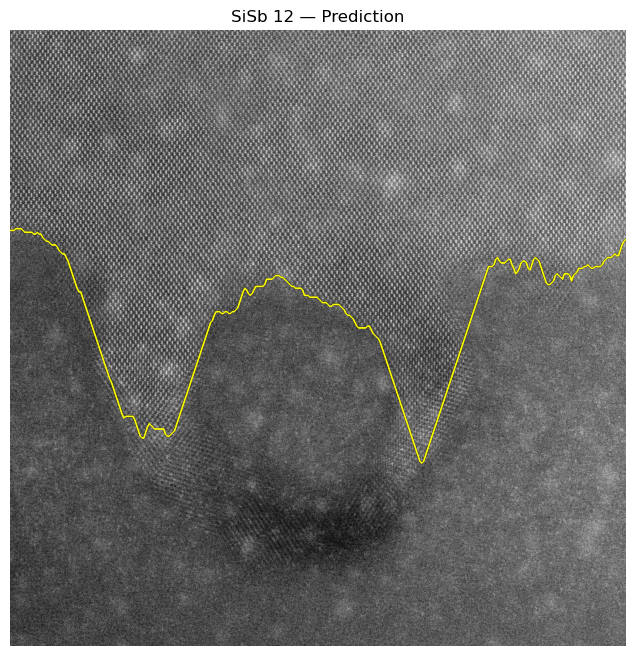

In [204]:
example_index = 11

image = sisb_images[example_index]
boundary = detect_boundary(image)

plot_boundary_result(
    image,
    boundary,
    title=f"SiSb {sisb_titles[example_index]} — Prediction",
)

In [205]:
def plot_all_boundary_results(
    images,
    titles,
    detector,
    rows=2,
    line_width=1.0,
):
    n = len(images)

    if n == 0:
        print("No images to display.")
        return

    cols = int(np.ceil(n / rows))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(3.5 * cols, 3.5 * rows),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for i, (image, title) in enumerate(zip(images, titles)):
        ax = axes[i]

        image = np.asarray(image)
        boundary = detector(image)

        # Original image
        ax.imshow(
            image,
            cmap="gray",
            vmin=np.percentile(image, 1),
            vmax=np.percentile(image, 99.5),
        )

        # Boundary overlay
        ax.contour(
            boundary,
            levels=[0.5],
            linewidths=line_width,
            colors="yellow"
        )

        ax.set_title(
            f"{title} — Prediction",
            fontsize=10
        )

        ax.axis("off")

    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.show()

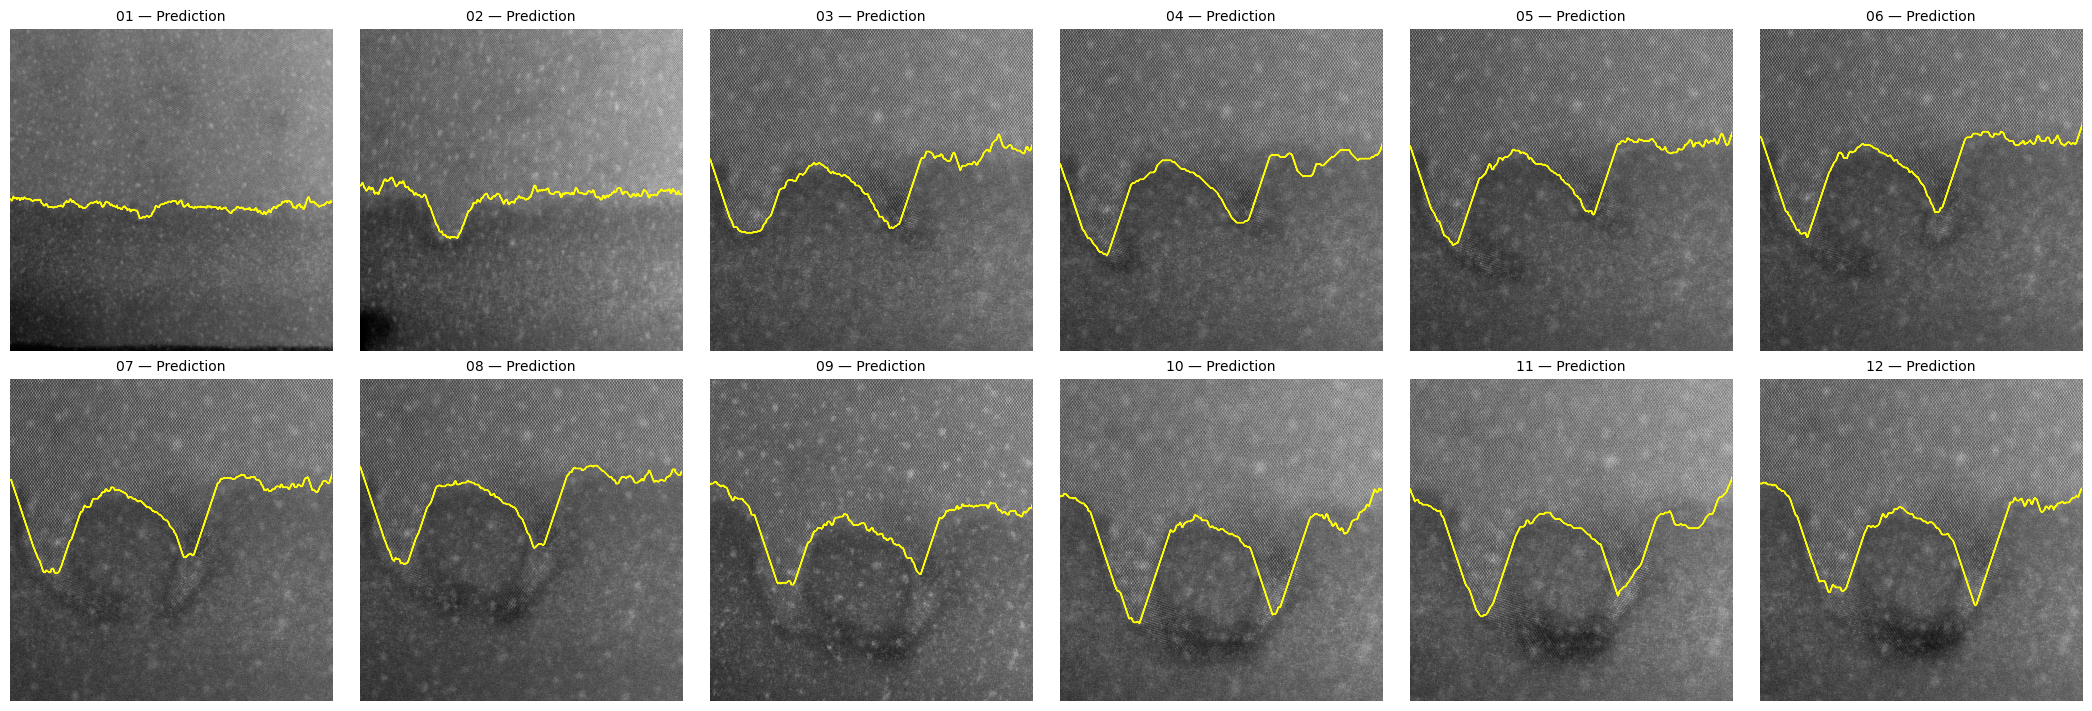

In [206]:
plot_all_boundary_results(
    sisb_images,
    sisb_titles,
    detect_boundary,
    rows=2,
)

## 5. Challenge 1 evaluation

We evaluate only three things:

### 1. Accuracy against human ground truth
Predictions are compared with the hand-drawn boundary using a spatial tolerance. Exact single-pixel agreement is not required.

Primary metric: **F1 @ 5 px tolerance**

### 2. Robustness
The same detector is tested after controlled perturbations:
- Gaussian noise
- Gaussian blur
- brightness change
- contrast change
- inclined intensity background

Every perturbed prediction is compared with the **same human ground truth**.

### 3. Speed
Only `detect_boundary(image)` is timed. File loading, plotting, and scoring are excluded.

### Test 1 — Accuracy against ground truth

In [207]:
accuracy_results = evaluate_against_ground_truth(
    detect_boundary,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=50,
)

accuracy_results

,image,precision,recall,f1,mean_pred_to_gt_distance,mean_gt_to_pred_distance,mean_symmetric_boundary_error
0,01,0.914883,0.967737,0.940568,27.844347,22.799752,25.322050
1,02,0.342039,0.559576,0.424564,63.653669,49.807060,56.730364
2,03,0.411912,0.454310,0.432073,63.065212,55.675317,59.370264
3,04,0.703478,0.657140,0.679520,39.526446,49.701179,44.613813
4,05,0.338531,0.310540,0.323932,67.677108,105.334265,86.505686
5,06,0.382515,0.342258,0.361268,65.206798,113.488688,89.347743
6,07,0.267850,0.208181,0.234276,79.326945,140.744377,110.035661
7,08,0.343455,0.247964,0.288000,66.914626,146.833655,106.874141
8,09,0.342827,0.216833,0.265647,65.535463,172.940470,119.237967
9,10,0.442158,0.361619,0.397853,54.731052,115.618320,85.174686


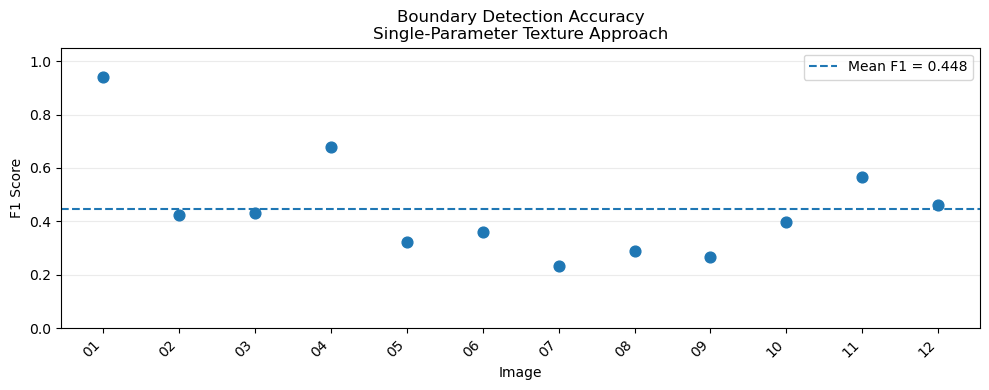

Mean F1: 0.448
Std F1:  0.192


In [208]:
# ============================================================
# Extract F1 scores
# ============================================================

f1_scores = accuracy_results["f1"].to_numpy()

image_names = sisb_titles


# ============================================================
# Save F1 scores
# ============================================================

f1_results = pd.DataFrame({
    "image": image_names,
    "f1_score": f1_scores,
})

f1_results.to_csv(
    "boundary_detection_f1_scores.csv",
    index=False
)


# ============================================================
# Dot plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(f1_scores))

ax.scatter(
    x,
    f1_scores,
    s=60,
    zorder=3
)

# Mean F1
mean_f1 = np.mean(f1_scores)

ax.axhline(
    mean_f1,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean F1 = {mean_f1:.3f}"
)

ax.set_xticks(x)
ax.set_xticklabels(image_names, rotation=45, ha="right")

ax.set_ylabel("F1 Score")
ax.set_xlabel("Image")
ax.set_ylim(0, 1.05)

ax.set_title(
    "Boundary Detection Accuracy\n"
    "Single-Parameter Texture Approach"
)

ax.grid(axis="y", alpha=0.25)

ax.legend()

plt.tight_layout()

plt.savefig(
    "boundary_detection_f1_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(f"Mean F1: {mean_f1:.3f}")
print(f"Std F1:  {np.std(f1_scores):.3f}")

In [209]:
summarize_accuracy(
    accuracy_results
)

mean_precision             0.477741
mean_recall                0.433224
mean_f1                    0.447754
mean_boundary_error_px    80.977955
Name: Clean boundary accuracy, dtype: float64

### Test 2 — Robustness

In [174]:
robustness_results = evaluate_robustness(
    detect_boundary,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=5,
    max_images=4,
)

robustness_summary = summarize_robustness(
    robustness_results
)

robustness_summary

,condition,mean_f1,std_f1,mean_precision,mean_recall,mean_boundary_error_px,f1_drop_from_clean
0,Clean,0.010949,0.018379,0.011353,0.010717,123.858949,0.000000
1,Gaussian noise 5%,0.008777,0.011952,0.009155,0.008990,124.229786,0.002172
2,Gaussian blur sigma=1,0.052745,0.073075,0.051392,0.055590,76.494230,-0.041796
3,Brightness +10%,0.010949,0.018379,0.011353,0.010717,123.858949,0.000000
4,Contrast -20%,0.010949,0.018379,0.011353,0.010717,123.858828,0.000000
5,Intensity gradient 20%,0.005653,0.010826,0.006348,0.005162,124.532119,0.005296


Interpretation:

- `mean_f1`: accuracy under that condition
- `mean_boundary_error_px`: average symmetric distance to the human boundary
- `f1_drop_from_clean`: performance lost relative to the clean images

**Smaller F1 drop is better.**

### Test 3 — Speed

In [210]:
speed_results = evaluate_speed(
    detect_boundary,
    sisb_images,
    repeats=1,
)

summarize_speed(
    speed_results
)

mean_seconds_per_image      3.712582
median_seconds_per_image    3.467417
slowest_seconds             4.988917
images_per_second           0.269354
Name: Speed, dtype: float64

# Challenge 2 — Atom Finding in YBCO

## Goal

Write:

```python
positions = find_atoms(image)
```

The function must return a NumPy array of shape `(N, 2)`.

Each row is:

```text
[y, x]
```

in pixel coordinates.

## 6. Load YBCO

In [ ]:
ybco_files = list_emd_files(YBCO_DIR)

ybco_images = [
    load_haadf(file)
    for file in ybco_files
]

ybco_titles = [
    file.stem
    for file in ybco_files
]

print(f"Found {len(ybco_images)} YBCO images")

if ybco_images:
    show_image_grid(
        ybco_images,
        titles=[
            str(i + 1)
            for i in range(len(ybco_images))
        ],
        rows=1 if len(ybco_images) > 1 else 1,
    )

## 7. Build your atom finder

A simple local-maximum baseline is provided.

You may completely replace the code between the two markers.

In [ ]:
def find_atoms(image):

    # ============================================================
    # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
    # ============================================================

    # 1. Normalize
    x = robust_normalize(image)

    # 2. Smooth
    smooth = ndimage.gaussian_filter(
        x,
        sigma=1.0
    )

    # 3. Find local maxima
    neighborhood = 5

    local_max = (
        smooth
        == ndimage.maximum_filter(
            smooth,
            size=neighborhood,
            mode="reflect",
        )
    )

    # 4. Keep only bright maxima
    intensity_threshold = np.percentile(
        smooth,
        97.0,
    )

    peaks = (
        local_max
        & (smooth >= intensity_threshold)
    )

    # 5. Convert peaks to [y, x]
    positions = np.argwhere(peaks)

    # ============================================================
    # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
    # ============================================================

    return np.asarray(
        positions
    ).reshape(-1, 2).astype(float)

## 8. Test one YBCO image visually

In [ ]:
if ybco_images:

    atom_example_index = 0

    atom_positions = find_atoms(
        ybco_images[atom_example_index]
    )

    validate_atom_output(
        ybco_images[atom_example_index],
        atom_positions,
    )

    plot_atom_result(
        ybco_images[atom_example_index],
        atom_positions,
        title="YBCO atom finding",
    )

## 9. Challenge 2 engineering tests

Until atom ground truth is added, these measure **consistency and robustness**, not true atom-detection accuracy.

In [ ]:
if ybco_images:
    atom_noise_results = atom_noise_robustness(
        find_atoms,
        ybco_images,
        noise_levels=(0.01, 0.03, 0.05, 0.10),
        tolerance=2.0,
    )

atom_noise_results

In [ ]:
if ybco_images:
    atom_photometric_results = atom_photometric_robustness(
        find_atoms,
        ybco_images,
        tolerance=2.0,
    )

atom_photometric_results

In [ ]:
if ybco_images:

    atom_speed_results = evaluate_speed(
        find_atoms,
        ybco_images,
        repeats=5,
    )

summarize_speed(
        atom_speed_results
    )

# 10. Reflection

At the end of the session, be ready to explain:

1. What approach did you use?
2. Which parameters matter most?
3. Where does it fail?
4. What would you improve next?
5. If AI helped write code, what did it generate?
6. What did you personally change?

> A good scientific algorithm is not just one that gives a nice picture.  
> You should be able to explain **how accurate, robust, and fast it is**.